# Прод. МО - ЛР1 - Этап тестировки

In [1]:
!pip install -q optuna

In [2]:
from ConstructiveNumber import ConstructiveNumber as CR
from Functions import QuadraticFunction, RosenbrockFunction, CallCounter
from Optimization import GradientDescent, DownhillSimplexMethod

import numpy as np
import pandas as pd

import time

import optuna

import matplotlib.pyplot as plt

## Инициализация

In [3]:
gd = GradientDescent()
nm = DownhillSimplexMethod()

# квадратичная 6-арная с хорошей обусловленностью (kappa = 1.0)
A_good = np.eye(6)
b_good = np.array([-1.0, 1.0, -2.0, 2.0, -0.5, 0.5])
quad_good = QuadraticFunction(A=A_good, b=b_good, c=0.0)

# квадратичная 4-арная с плохой обусловленностью (kappa = 100.0)
A_bad = np.diag([1.0, 10.0, 50.0, 100.0])
b_bad = -A_bad @ np.array([1.0, 1.0, 1.0, 1.0])
quad_bad = QuadraticFunction(A=A_bad, b=b_bad, c=0.0)

# функция Розенброка 3-арная
rosenbrock = RosenbrockFunction()

Функция визуализации

In [4]:
# строит 2д срез и накладывает пути оптимизации GD и NM
def plot_optimization_contour(
    func,
    res_gd,
    res_nm,
    target_min,
    dims=(0, 1),
    title="Траектории оптимизации",
    levels=40, # количество линий уровня
    pad=0.5, # отступ по краям графика
    log_levels=False,
):
    d1, d2 = dims

# вытаскиваем траекторию для обоих методов
    def extract_coords(history):
        coords = []
        for point in history:
            if isinstance(point[0], CR):
                coords.append([p.get_real_value() for p in point])
            else:
                coords.append(list(point))
        return np.array(coords)

    traj_gd = extract_coords(res_gd.history)
    traj_nm = extract_coords(res_nm.history)

    # Определяем границы сетки по крайним точкам траекторий и оптимума
    all_x = np.concatenate([traj_gd[:, d1], traj_nm[:, d1], [target_min[d1]]])
    all_y = np.concatenate([traj_gd[:, d2], traj_nm[:, d2], [target_min[d2]]])

    x_min, x_max = np.min(all_x) - pad, np.max(all_x) + pad
    y_min, y_max = np.min(all_y) - pad, np.max(all_y) + pad

    # Создаем регулярную 2D сетку
    grid_x = np.linspace(x_min, x_max, 150)
    grid_y = np.linspace(y_min, y_max, 150)
    X, Y = np.meshgrid(grid_x, grid_y)

    # Вычисляем значения функции в узлах сетки
    Z = np.zeros_like(X)
    fixed_point = np.array(target_min, dtype=float).copy()

    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            pt = fixed_point.copy()
            pt[d1] = X[i, j]
            pt[d2] = Y[i, j]
            val = func(pt)
            Z[i, j] = (
                val.get_real_value()
                if isinstance(val, CR)
                else float(val)
            )

    plt.figure(figsize=(9, 7))

    # Линии уровня (для Розенброка используется логарифмическая шкала уровней)
    if log_levels:
        Z_shifted = Z - np.min(Z) + 1e-4
        lvls = np.logspace(
            np.log10(np.min(Z_shifted)), np.log10(np.max(Z_shifted)), levels
        )
        cs = plt.contour(
            X,
            Y,
            Z_shifted,
            levels=lvls,
            cmap="viridis",
            alpha=0.6,
            linestyles="dashed",
        )
    else:
        cs = plt.contour(
            X, Y, Z, levels=levels, cmap="viridis", alpha=0.6, linestyles="dashed"
        )

    plt.clabel(cs, inline=True, fontsize=8, fmt="%.1f")

    # Траектория градиентного спуска (GD)
    plt.plot(
        traj_gd[:, d1],
        traj_gd[:, d2],
        color="royalblue",
        marker="o",
        markersize=3,
        linewidth=1.5,
        label=f"GD",
    )

    # Траектория метода Нелдера-Мида (NM)
    plt.plot(
        traj_nm[:, d1],
        traj_nm[:, d2],
        color="darkorange",
        marker="s",
        markersize=3,
        linewidth=1.5,
        label=f"NM",
    )

    # Маркеры старта и минимумов
    plt.scatter(
        [traj_gd[0, d1]],
        [traj_gd[0, d2]],
        color="red",
        s=67,
        zorder=5,
        label="Старт",
    )
    plt.scatter(
        [target_min[d1]],
        [target_min[d2]],
        color="lime",
        s=67,
        zorder=5,
        label="Минимум",
    )

    plt.title(title, fontsize=12)
    plt.xlabel(f"Координата $x_{d1 + 1}$")
    plt.ylabel(f"Координата $x_{d2 + 1}$")
    plt.legend(loc="best")
    plt.grid(True, linestyle=":", alpha=0.5)
    plt.show()

In [5]:
# табличное отображение результатов оптимизации
def display_optimization_result(f_counter, true_min, opt_res, opt_time, method_name):
    print(method_name)
    coords_df = pd.DataFrame(columns=[f"x_{i+1}" for i in range(len(true_min))])
    coords_df.loc[0] = [f"({round(coord.a, 3)}, {round(coord.b, 3)})" for coord in opt_res.x]
    coords_df.loc[1] = [round(coord.get_real_value(), 3) for coord in opt_res.x]
    coords_df.loc[2] = true_min
    coords_df.index = ["Интервал", "Центр", "Истинный минимум"]
    display(coords_df)
    print(f"Итераций: {opt_res.iters}, Время: {opt_time:.5f}с, Вызовов функции: {f_counter.calls}, Вызовов градиента: {f_counter.grad_calls}")
    print()
    print("-" * 90)
    del coords_df

## Тест 1 - Квадратичная 6-арная (k=1)

In [6]:
x0 = np.array([CR(x=0.0, eps=1e-3) for _ in range(6)], dtype=object)
target_q6 = np.array([1.0, -1.0, 2.0, -2.0, 0.5, -0.5])

# подбор оптимального learning rate
def objective(trial):
    a = trial.suggest_float('a', 0, 1)

    gd_res = gd.optimize(quad_good, x0, a=a, tol=1e-3)
    gd_res_x = np.array([coord.get_real_value() for coord in gd_res.x])
    true_min = target_q6
    
    return np.sum(np.abs(gd_res_x - true_min))

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100)
best_a = study.best_params["a"]
print(f"Лучший learning rate: {best_a}")
print()

# Запуск GD
f_gd = CallCounter(quad_good)
t0 = time.perf_counter()
res_gd = gd.optimize(f_gd, x0, a=best_a, tol=1e-3)
time_gd = time.perf_counter() - t0

display_optimization_result(f_gd, target_q6, res_gd, time_gd, "Градиентный спуск")

# Запуск NM
f_nm = CallCounter(quad_good)
t0 = time.perf_counter()
res_nm = nm.optimize(f_nm, x0, tol=1e-3)
time_nm = time.perf_counter() - t0

display_optimization_result(f_nm, target_q6, res_nm, time_nm, "Метод Нелдера-Мида")

Лучший learning rate: 0.9995869066125254

Градиентный спуск


,x_1,x_2,x_3,x_4,x_5,x_6
Интервал,"(0.999, 1.001)","(-1.001, -0.999)","(1.999, 2.001)","(-2.001, -1.999)","(0.499, 0.501)","(-0.501, -0.499)"
Центр,1.0,-1.0,2.0,-2.0,0.5,-0.5
Истинный минимум,1.0,-1.0,2.0,-2.0,0.5,-0.5


Итераций: 3, Время: 0.00036с, Вызовов функции: 4, Вызовов градиента: 3

------------------------------------------------------------------------------------------
Метод Нелдера-Мида


,x_1,x_2,x_3,x_4,x_5,x_6
Интервал,"(0.999, 1.001)","(-1.001, -0.999)","(1.999, 2.001)","(-2.001, -1.999)","(0.499, 0.501)","(-0.501, -0.499)"
Центр,1.0,-1.0,2.0,-2.0,0.5,-0.5
Истинный минимум,1.0,-1.0,2.0,-2.0,0.5,-0.5


Итераций: 113, Время: 0.00876с, Вызовов функции: 1094, Вызовов градиента: 0

------------------------------------------------------------------------------------------


### ГРАФИК: Тест 1

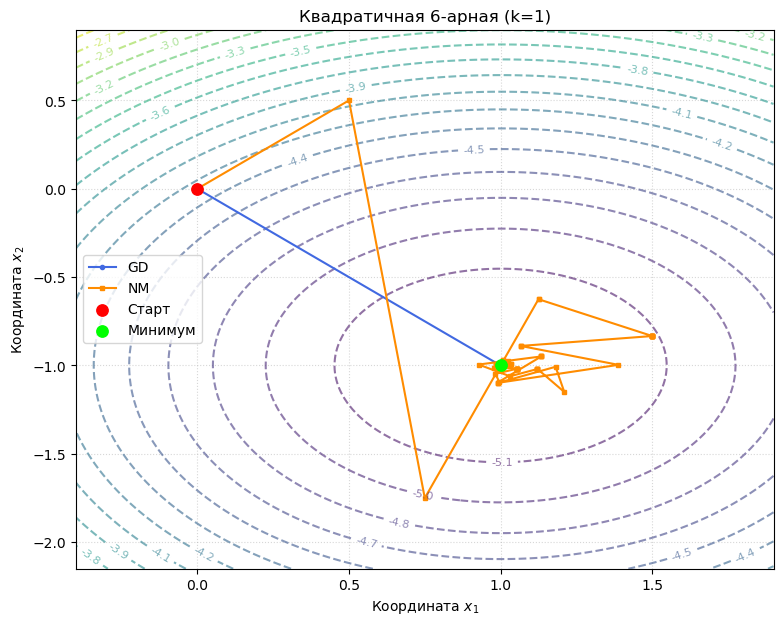

In [7]:
plot_optimization_contour(
    func=quad_good,
    res_gd=res_gd,
    res_nm=res_nm,
    target_min=target_q6,
    dims=(0, 1),
    title="Квадратичная 6-арная (k=1)",
    levels=25,
    pad=0.4,
)

## Тест 2 - Квадратичная 4-арная (k=100)

p.s. границы learning rate - (0, 0.2), потому что GD гаранированно сходится при условии: $lr < \frac{2}{\lambda_{\text{max}}}$. \
У нас матрица $A = diag(1, 10, 50, 100)$, поэтому $\lambda_{\text{max}} = 100$

In [8]:
x0 = np.array([CR(x=0.0, eps=1e-2) for _ in range(4)], dtype=object)
target_q4 = np.array([1.0, 1.0, 1.0, 1.0])

# подбор оптимального learning rate
def objective(trial):
    a = trial.suggest_float('a', 0, 0.02)

    gd_res = gd.optimize(quad_bad, x0, a=a, tol=1e-3)
    gd_res_x = np.array([coord.get_real_value() for coord in gd_res.x])
    true_min = target_q4
    
    return np.sum(np.abs(gd_res_x - true_min))

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100)
best_a = study.best_params["a"]
print(f"Лучший learning rate: {best_a}")
print()

# Запуск GD
f_gd = CallCounter(quad_bad)
t0 = time.perf_counter()
res_gd = gd.optimize(f_gd, x0, a=best_a, tol=1e-2, max_iters=2000)
time_gd = time.perf_counter() - t0

display_optimization_result(f_gd, target_q4, res_gd, time_gd, "Градиентный спуск")

# Запуск NM
f_nm = CallCounter(quad_bad)
t0 = time.perf_counter()
res_nm = nm.optimize(f_nm, x0, tol=1e-2, max_iters=2000)
time_nm = time.perf_counter() - t0

display_optimization_result(f_nm, target_q4, res_nm, time_nm, "Метод Нелдера-Мида")

Лучший learning rate: 0.019883038857715474

Градиентный спуск


,x_1,x_2,x_3,x_4
Интервал,"(0.99, 1.01)","(0.99, 1.01)","(0.99, 1.01)","(0.99, 1.01)"
Центр,1.0,1.0,1.0,1.0
Истинный минимум,1.0,1.0,1.0,1.0


Итераций: 784, Время: 0.04251с, Вызовов функции: 785, Вызовов градиента: 784

------------------------------------------------------------------------------------------
Метод Нелдера-Мида


,x_1,x_2,x_3,x_4
Интервал,"(0.983, 1.003)","(0.993, 1.013)","(0.99, 1.01)","(0.992, 1.012)"
Центр,0.993,1.003,1.0,1.002
Истинный минимум,1.0,1.0,1.0,1.0


Итераций: 49, Время: 0.00254с, Вызовов функции: 382, Вызовов градиента: 0

------------------------------------------------------------------------------------------


## График: Тест 2


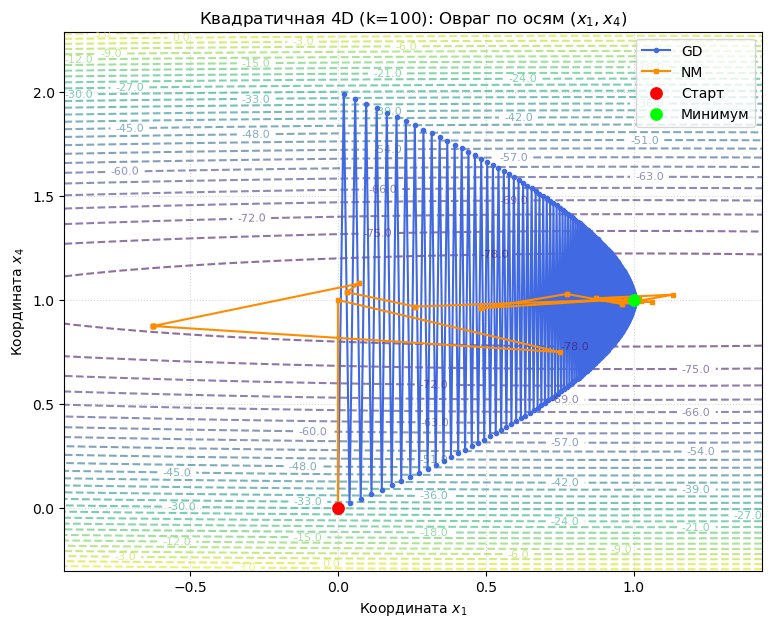

In [9]:
plot_optimization_contour(
    func=quad_bad,
    res_gd=res_gd,
    res_nm=res_nm,
    target_min=target_q4,
    dims=(0, 3),  # 0 -> x1, 3 -> x4
    title="Квадратичная 4D (k=100): Овраг по осям $(x_1, x_4)$",
    levels=30,
    pad=0.3,
)

## Тест 3 - Функция Розенброка 3-арная

In [10]:
x0 = np.array([CR(x=1.2, eps=1e-3) for _ in range(3)], dtype=object)
target_rb = np.array([1.0, 1.0, 1.0])

# подбор оптимального learning rate
def objective(trial):
    a = trial.suggest_float('a', 0, 0.001)

    gd_res = gd.optimize(rosenbrock, x0, a=a, tol=1e-3)
    gd_res_x = np.array([coord.get_real_value() for coord in gd_res.x])
    true_min = target_rb
    
    return np.sum(np.abs(gd_res_x - true_min))

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100)
best_a = study.best_params["a"]
print(f"Лучший learning rate: {best_a}")
print()

# Запуск GD
f_gd = CallCounter(rosenbrock)
t0 = time.perf_counter()
res_gd = gd.optimize(f_gd, x0, a=best_a, tol=1e-3, max_iters=3000)
time_gd = time.perf_counter() - t0

display_optimization_result(f_gd, target_rb, res_gd, time_gd, "Градиентный спуск")

# Запуск NM
f_nm = CallCounter(rosenbrock)
t0 = time.perf_counter()
res_nm = nm.optimize(f_nm, x0, tol=1e-3, max_iters=3000)
time_nm = time.perf_counter() - t0

display_optimization_result(f_nm, target_rb, res_nm, time_nm, "Метод Нелдера-Мида")

Лучший learning rate: 0.0009998441526784376

Градиентный спуск


,x_1,x_2,x_3
Интервал,"(1.016, 1.018)","(1.033, 1.035)","(1.068, 1.07)"
Центр,1.017,1.034,1.069
Истинный минимум,1.0,1.0,1.0


Итераций: 3000, Время: 0.09128с, Вызовов функции: 3002, Вызовов градиента: 3000

------------------------------------------------------------------------------------------
Метод Нелдера-Мида


,x_1,x_2,x_3
Интервал,"(0.999, 1.001)","(0.999, 1.001)","(0.999, 1.001)"
Центр,1.0,1.0,1.0
Истинный минимум,1.0,1.0,1.0


Итераций: 77, Время: 0.00190с, Вызовов функции: 516, Вызовов градиента: 0

------------------------------------------------------------------------------------------


## График: Тест 3

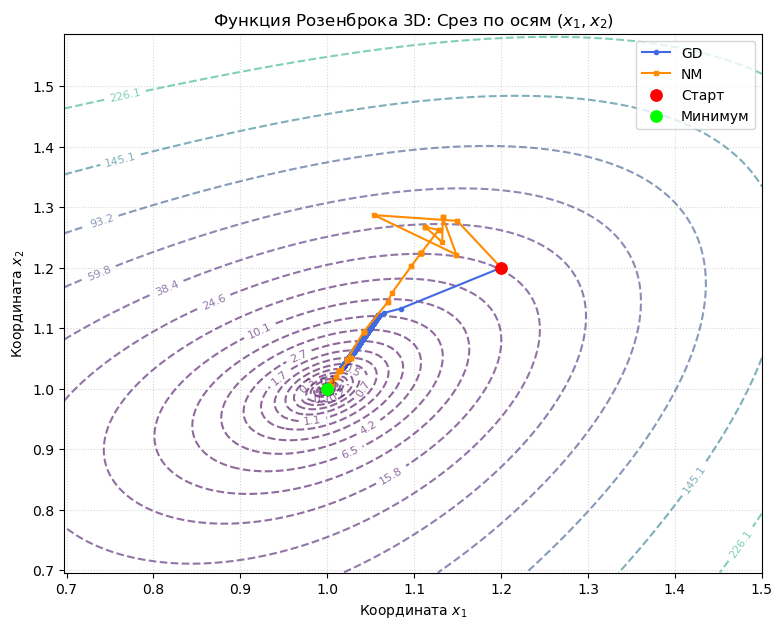

In [11]:
plot_optimization_contour(
    func=rosenbrock,
    res_gd=res_gd,
    res_nm=res_nm,
    target_min=target_rb,
    dims=(0, 1),
    title="Функция Розенброка 3D: Срез по осям $(x_1, x_2)$",
    levels=35,
    pad=0.3,
    log_levels=True,
)

## Исследование динамики eps

Формирование датасета

In [12]:
eps_orders = [1e-1, 1e-2, 1e-4]

experiments = {
    "Квадратичная 6D (k=1)": {
        "func": quad_good,
        "x0_center": np.zeros(6, dtype=float),
        "gd_a": 0.2,
        "tol": 1e-3,
        "max_iters": 500,
    },
    "Квадратичная 4D (k=100)": {
        "func": quad_bad,
        "x0_center": np.zeros(4, dtype=float),
        "gd_a": 0.01,
        "tol": 1e-2,
        "max_iters": 1000,
    },
    "Функция Розенброка 3D": {
        "func": rosenbrock,
        "x0_center": np.array([1.2, 1.2, 1.2], dtype=float),
        "gd_a": 1e-3,
        "tol": 1e-3,
        "max_iters": 1000,
    },
}

eps_data = {fname: {"GD": {}, "NM": {}} for fname in experiments}

for fname, cfg in experiments.items():
    f = cfg["func"]
    c = cfg["x0_center"]

    for eps_val in eps_orders:
        # Формируем интервальную стартовую точку
        x0_cr = np.array(
            [CR(x=val, eps=eps_val) for val in c], dtype=object
        )

        # 1. Запуск Градиентного спуска
        res_gd = gd.optimize(
            f, x0_cr, a=cfg["gd_a"], tol=cfg["tol"], max_iters=cfg["max_iters"]
        )
        eps_data[fname]["GD"][eps_val] = res_gd.eps_history

        # 2. Запуск Метода Нелдера-Мида
        res_nm = nm.optimize(
            f, x0_cr, tol=cfg["tol"], max_iters=cfg["max_iters"]
        )
        eps_data[fname]["NM"][eps_val] = res_nm.eps_history

Визуализация

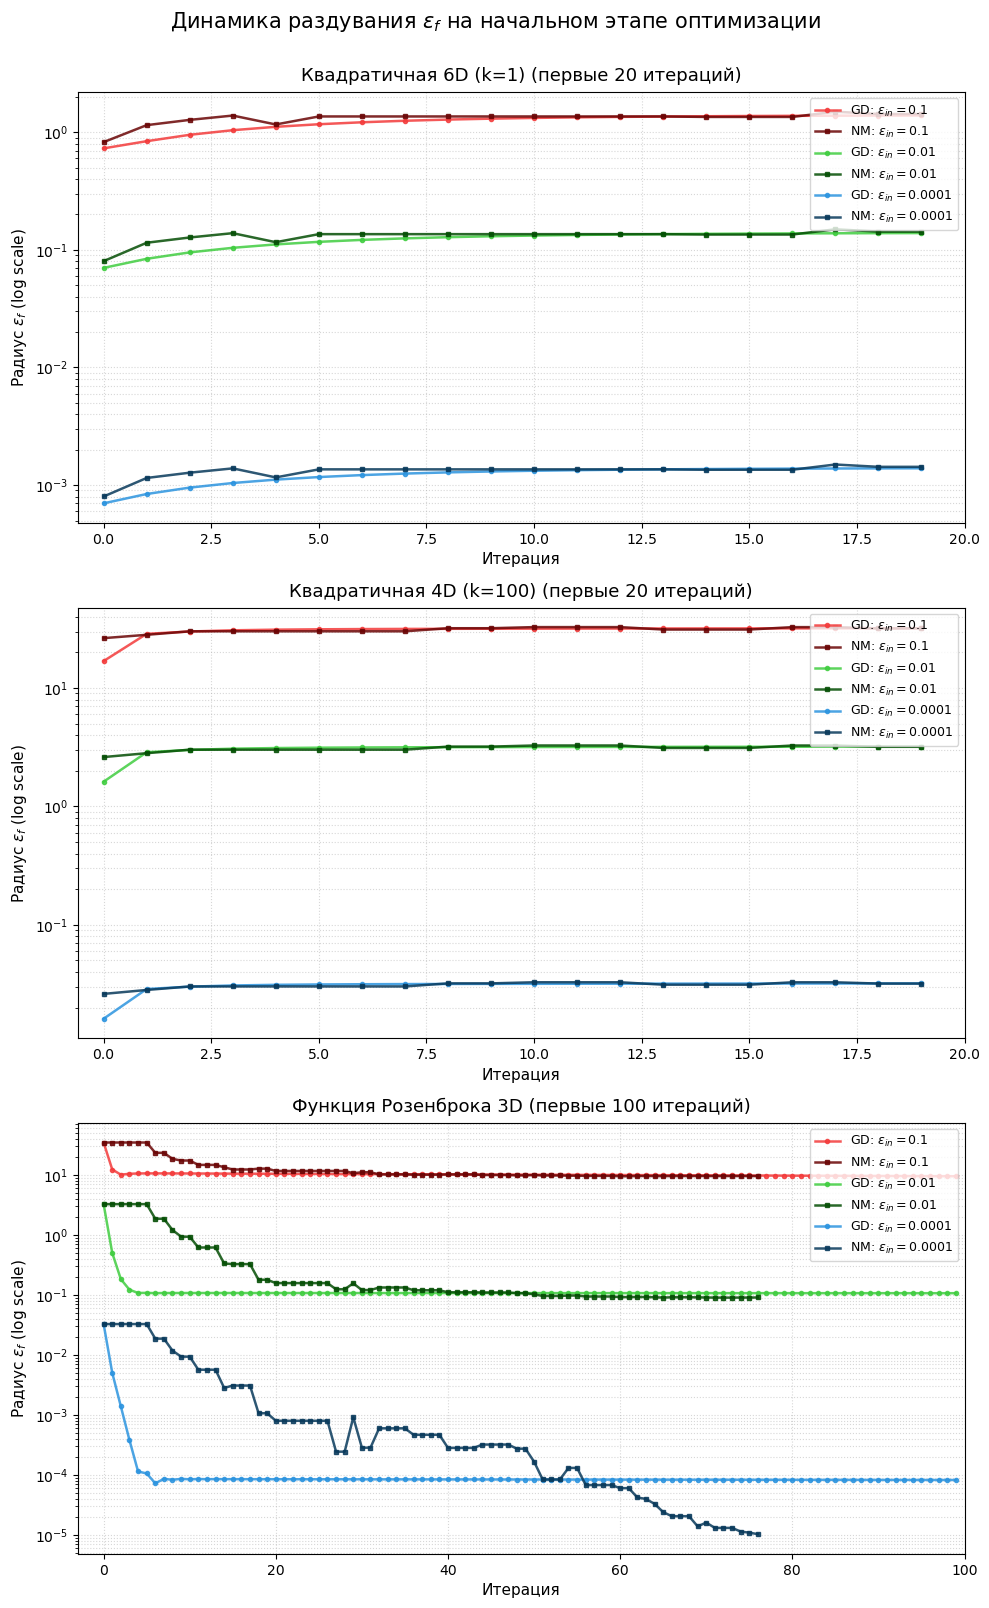

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(10, 16), sharey=False)

colorsGD = {1e-1: "#f33b3b", 1e-2: "#40cd40", 1e-4: "#2c94df"}
colorsNM = {1e-1: "#6A0505", 1e-2: "#044e04", 1e-4: "#08395b"}

# тут я приближаю на график самый активный начальный момент, тк далее на итерациях 100-1000 eps вообще не меняется
iteration_limits = {
    "Квадратичная 6D (k=1)": 20,
    "Квадратичная 4D (k=100)": 20,
    "Функция Розенброка 3D": 100,
}

for ax, (fname, methods_res) in zip(axes, eps_data.items()):
    lim = iteration_limits[fname]

    for eps_val in eps_orders:
        colGD = colorsGD[eps_val]
        colNM = colorsNM[eps_val]

        hist_gd = methods_res["GD"][eps_val][:lim]
        hist_nm = methods_res["NM"][eps_val][:lim]

        # GD (светлее)
        ax.plot(
            range(len(hist_gd)),
            hist_gd,
            linestyle="-",
            marker="o",
            markersize=3,
            color=colGD,
            alpha=0.85,
            linewidth=1.8,
            label=f"GD: $\\varepsilon_{{in}} = {eps_val}$",
        )

        # NM (темнее)
        ax.plot(
            range(len(hist_nm)),
            hist_nm,
            linestyle="-",
            marker="s",
            markersize=3,
            color=colNM,
            alpha=0.85,
            linewidth=1.8,
            label=f"NM: $\\varepsilon_{{in}} = {eps_val}$",
        )

    # Делаем аккуратный отступ слева на 3% от диапазона
    ax.set_xlim(left=-lim * 0.03, right=lim)

    ax.set_title(f"{fname} (первые {lim} итераций)", fontsize=13, pad=8)
    ax.set_xlabel("Итерация", fontsize=11)
    ax.set_ylabel("Радиус $\\varepsilon_f$ (log scale)", fontsize=11)
    ax.set_yscale("log")
    ax.grid(True, which="both", linestyle=":", alpha=0.5)
    ax.legend(fontsize=9, loc="upper right")

plt.suptitle(
    "Динамика раздувания $\\varepsilon_f$ на начальном этапе оптимизации",
    fontsize=15,
    y=1.002,
)
plt.tight_layout()
plt.show()